We will use kmeans clustering to figure out the species of the penguins

In [68]:
# standard packaging

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt

sns.set(color_codes=True, rc={'figure.figsize':(10,8)})



In [69]:
data = pd.read_csv('data/bcn_noise_class_ml_dataset.csv')

Data prep

In [70]:
data_clean = data.dropna(how = "any")
data_clean.info()
data_clean.reset_index(inplace=True, drop = True)
data_clean.head()

<class 'pandas.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                12854 non-null  str    
 1   noise_day              12854 non-null  int64  
 2   noise_evening          12854 non-null  int64  
 3   noise_night            12854 non-null  int64  
 4   road_category          12854 non-null  int64  
 5   dist_to_trunk          12854 non-null  float64
 6   dist_to_primary        12854 non-null  float64
 7   dist_to_secondary      12854 non-null  float64
 8   dist_to_tertiary       12854 non-null  float64
 9   dist_to_residential    12854 non-null  float64
 10  dist_to_living_street  12854 non-null  float64
 11  signals                12854 non-null  float64
 12  transport              12854 non-null  float64
 13  pois                   12854 non-null  float64
 14  width                  12854 non-null  float64
 15  betweenness  

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,13859746870_13859746860_0,2,2,2,5,213.093233,512.208689,1110.052349,188.355179,0.0,...,0.000000,0.106597,50.000000,0.000039,0.000187,0.000017,0.807756,3.349277,0.0,0.0
1,13798851565_8465472214_0,2,2,1,5,549.529452,1655.791584,2110.530434,351.777378,0.0,...,0.014274,0.000000,20.006115,0.000224,0.000109,0.000004,0.741368,0.000000,0.0,0.0
2,4538123419_13734642240_0,3,3,3,3,904.118521,947.154817,0.000000,167.026629,0.0,...,0.000000,0.295484,50.000000,0.010452,0.000182,0.000018,0.831327,8.619238,0.0,0.0
3,13845167536_847716886_0,2,2,1,5,1877.603526,419.287598,661.587375,10.597441,0.0,...,0.012453,0.002491,16.759462,0.004427,0.000215,0.000009,0.757172,4.346695,0.0,0.0
4,13845167536_253790691_0,2,2,2,5,1872.177506,614.353897,967.746460,0.000000,0.0,...,0.053513,0.000000,50.000000,0.003735,0.000208,0.000006,0.736805,25.169641,0.0,0.0


Encode the variables

In [71]:
y = data_clean.noise_day
#encoding categorical variables
X = data_clean.drop(columns=['road_id','noise_day','noise_evening', 'noise_night'])
X = pd.get_dummies(X)
X.head()

,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,signals,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,5,213.093233,512.208689,1110.052349,188.355179,0.0,385.612798,0.053298,0.000000,0.106597,50.000000,0.000039,0.000187,0.000017,0.807756,3.349277,0.0,0.0
1,5,549.529452,1655.791584,2110.530434,351.777378,0.0,117.669324,0.000000,0.014274,0.000000,20.006115,0.000224,0.000109,0.000004,0.741368,0.000000,0.0,0.0
2,3,904.118521,947.154817,0.000000,167.026629,0.0,19.810222,0.167307,0.000000,0.295484,50.000000,0.010452,0.000182,0.000018,0.831327,8.619238,0.0,0.0
3,5,1877.603526,419.287598,661.587375,10.597441,0.0,41.365655,0.000000,0.012453,0.002491,16.759462,0.004427,0.000215,0.000009,0.757172,4.346695,0.0,0.0
4,5,1872.177506,614.353897,967.746460,0.000000,0.0,49.109562,0.000000,0.053513,0.000000,50.000000,0.003735,0.000208,0.000006,0.736805,25.169641,0.0,0.0


Training attempt

In [72]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=5)
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [73]:
# Using the predict method of KMeans to predict 3 clusters using the sample data

labels = model.predict(X)

In [74]:
# We plot a cross tab matrix to check how well has our K-Means model classified the Species

matrix = pd.DataFrame({'labels': labels, 'species': y})
ct = pd.crosstab(matrix['labels'], matrix['species'])
print(ct)

species   0    1    2     3    4
labels                          
0         9   77  927  2043  387
1        49  187  931  1207  102
2        45   82  107   142    2
3         7   43  757  2251  817
4        22  193  983  1269  215


Now standard scaling ?


In [75]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [76]:
X_scaled = scaler.fit_transform(X)

In [77]:
#Train another model
model_2 = KMeans(n_clusters=5)
model_2.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [78]:
labels_ss = model_2.predict(X_scaled)

In [79]:
#plotting the Cross-tab matrix with the new labels

matrix_new = pd.DataFrame({'labels': labels_ss, 'noise': y})
ct_new = pd.crosstab(matrix_new['labels'], matrix_new['noise'])
print(ct_new)

noise     0    1     2     3    4
labels                           
0         2    0   129  2017  915
1        11  126  1648  2594  415
2        19  247  1585  1967  187
3       100  203   242   174    4
4         0    6   101   160    2


In [80]:
data_clean["kmeansLabels"] = labels_ss

See where the problem is

<Axes: xlabel='straightness', ylabel='closeness_global'>

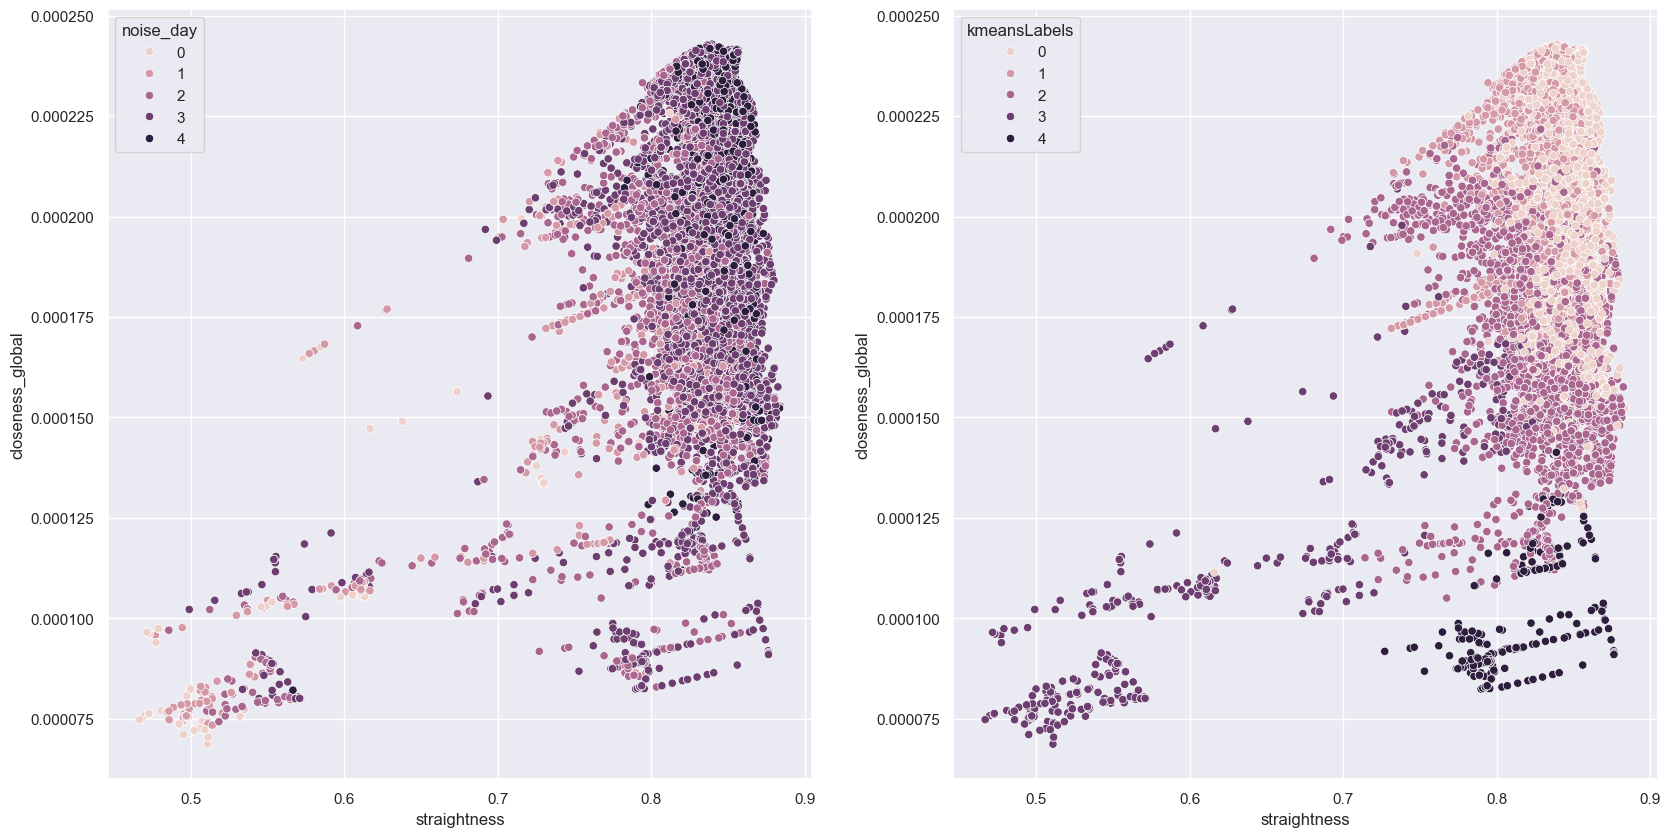

In [85]:
#create two plots side by side

fig, (ax1, ax2) = plt.subplots(ncols=2,  figsize = (20,10))
sns.scatterplot(x="straightness", y="closeness_global", data = data_clean, hue = "noise_day", ax=ax1)
sns.scatterplot(x="straightness", y="closeness_global", data = data_clean, hue = "kmeansLabels", ax=ax2)

NameError: name 'penguins_clean' is not defined

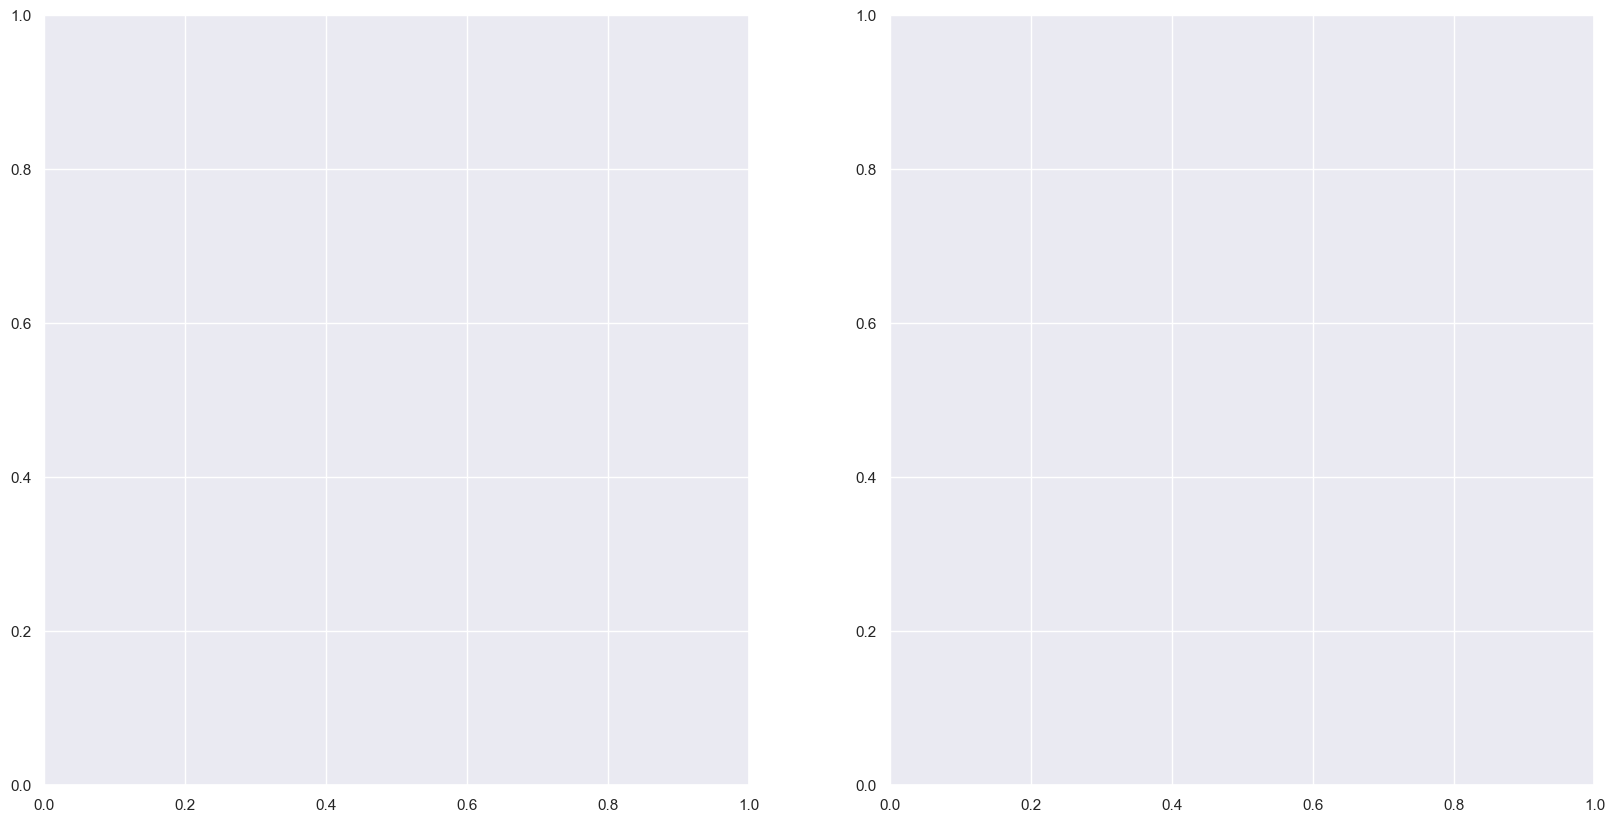

In [ ]:
#create two plots side by side

fig, (ax1, ax2) = plt.subplots(ncols=2,  figsize = (20,10))
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", data = penguins_clean, hue = "species_short", ax=ax1)
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", data = penguins_clean, hue = "kmeansLabels", ax=ax2)

# now with only 2 variables

In [ ]:
import numpy as np
X_scaled_select = X_scaled[:, [0, 2]]

In [ ]:
#Train another model
model_3 = KMeans(n_clusters=3)
model_3.fit(X_scaled_select)
labels_select = model_3.predict(X_scaled_select)

In [ ]:
#plotting the Cross-tab matrix with the new labels

matrix_new = pd.DataFrame({'labels': labels_select, 'species': y})
ct_new = pd.crosstab(matrix_new['labels'], matrix_new['species'])
print(ct_new)

species  Adelie  Chinstrap  Gentoo
labels                            
0             1          4     119
1           141          5       0
2             4         59       1


In [ ]:
penguins_clean["kmeansLabels"] = labels_select

/tmp/ipykernel_11579/1071958234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_clean["kmeansLabels"] = labels_select


<Axes: xlabel='culmen_length_mm', ylabel='flipper_length_mm'>

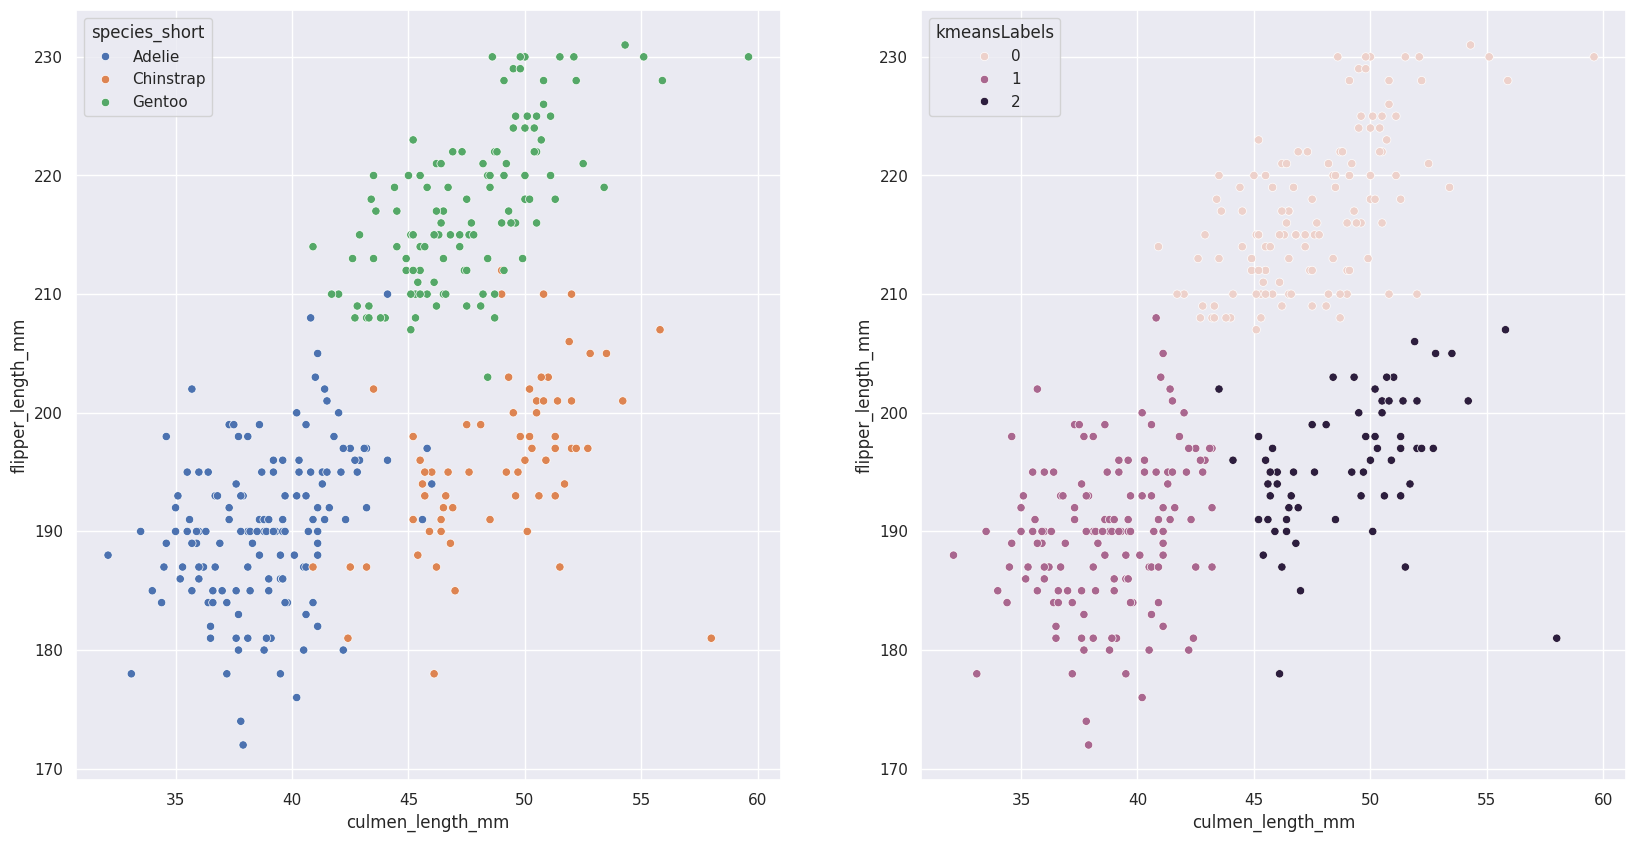

In [ ]:
#create two plots side by side

fig, (ax1, ax2) = plt.subplots(ncols=2,  figsize = (20,10))
sns.scatterplot(x="culmen_length_mm", y="flipper_length_mm", data = penguins_clean, hue = "species_short", ax=ax1)
sns.scatterplot(x="culmen_length_mm", y="flipper_length_mm", data = penguins_clean, hue = "kmeansLabels", ax=ax2)